In [1]:
!pip install -q datasets scikit-learn pandas matplotlib

import pandas as pd
from datasets import load_dataset

In [3]:
ds = load_dataset("masakhane/masakhanews", "run")
print(ds)

train.tsv:   0%|          | 0.00/3.33M [00:00<?, ?B/s]

dev.tsv:   0%|          | 0.00/495k [00:00<?, ?B/s]

test.tsv:   0%|          | 0.00/950k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1117 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/159 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/322 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['category', 'headline', 'text', 'url'],
        num_rows: 1117
    })
    validation: Dataset({
        features: ['category', 'headline', 'text', 'url'],
        num_rows: 159
    })
    test: Dataset({
        features: ['category', 'headline', 'text', 'url'],
        num_rows: 322
    })
})


In [4]:
import pandas as pd

train = pd.DataFrame(ds["train"])
val = pd.DataFrame(ds["validation"])
test = pd.DataFrame(ds["test"])

# 1. One example
print(train.iloc[0][["category", "headline"]])
print(train.iloc[0]["text"][:400])
print()

# 2. Class balance in each split
print("TRAIN")
print(train["category"].value_counts())
print("\nVALIDATION")
print(val["category"].value_counts())
print("\nTEST")
print(test["category"].value_counts())

# 3. Text length (in words)
print("\nWords per article (train):")
print(train["text"].str.split().str.len().describe())

# 4. Missing or duplicate texts
print("\nMissing text:", train["text"].isna().sum())
print("Duplicate texts in train:", train["text"].duplicated().sum())
print("Train texts that also appear in test:",
      train["text"].isin(test["text"]).sum())

category                                               sports
headline    Ayavugwa mw’igura n’igurishwa ry’abakinyi: Kan...
Name: 0, dtype: object
Barcelona irashobora guheraheza amasezerano yo kugura umufaransa akina hagati  N'Golo Kante, mu kwa mbere, ariko bikazovana n'ingene imvune yiwe yo mw'itako izoba imeze, amasezerano afitaniye na  Chelsea akaba azorangira mu ci riza. (Sport) AC Milan ishobora guhagarika urugamba rwayo rwo kurondera umukinyi wo ku ruhande wa  Chelsea, Hakim Ziyech w'imyaka  29, kubera ivyo uyu mukinyi mpuzamakungu w

TRAIN
category
politics         350
sports           293
health           260
entertainment    110
business          53
religion          51
Name: count, dtype: int64

VALIDATION
category
politics         50
sports           42
health           37
entertainment    16
business          7
religion          7
Name: count, dtype: int64

TEST
category
politics         100
sports            84
health            75
entertainment     32
business          

VALIDATION  acc: 0.937  macro-F1: 0.898
TEST  acc: 0.863  macro-F1: 0.776  weighted-F1: 0.859

               precision    recall  f1-score   support

     business      0.636     0.438     0.519        16
entertainment      0.742     0.719     0.730        32
       health      0.852     0.920     0.885        75
     politics      0.856     0.950     0.900       100
     religion      0.818     0.600     0.692        15
       sports      0.974     0.893     0.932        84

     accuracy                          0.863       322
    macro avg      0.813     0.753     0.776       322
 weighted avg      0.862     0.863     0.859       322



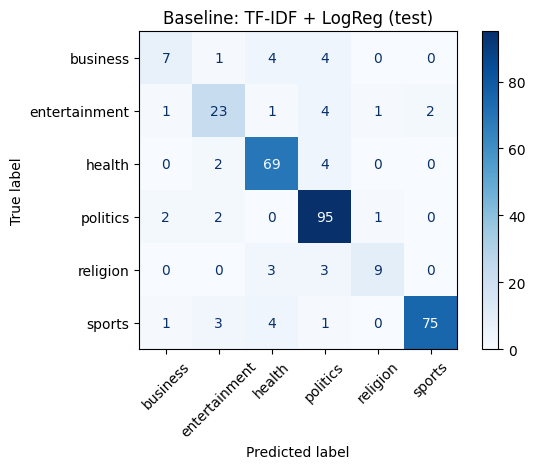

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import json

# Headline + text together
for df in (train, val, test):
    df["input"] = df["headline"].fillna("") + ". " + df["text"].fillna("")

vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                      sublinear_tf=True, min_df=2)
Xtr = vec.fit_transform(train["input"])
Xva = vec.transform(val["input"])
Xte = vec.transform(test["input"])

clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(Xtr, train["category"])

# Validation scores (used to compare settings)
pv = clf.predict(Xva)
print("VALIDATION  acc: %.3f  macro-F1: %.3f" % (
    accuracy_score(val["category"], pv),
    f1_score(val["category"], pv, average="macro")))

# Test scores (report these once, at the end)
pt = clf.predict(Xte)
acc = accuracy_score(test["category"], pt)
mf1 = f1_score(test["category"], pt, average="macro")
wf1 = f1_score(test["category"], pt, average="weighted")
print("TEST  acc: %.3f  macro-F1: %.3f  weighted-F1: %.3f" % (acc, mf1, wf1))
print()
print(classification_report(test["category"], pt, digits=3))

# Confusion matrix
labels = sorted(train["category"].unique())
cm = confusion_matrix(test["category"], pt, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    xticks_rotation=45, cmap="Blues")
plt.title("Baseline: TF-IDF + LogReg (test)")
plt.tight_layout()
plt.savefig("cm_baseline.png", dpi=150)
plt.show()

# Save results for the experiments table
results = {"baseline_tfidf_logreg": {"accuracy": acc, "macro_f1": mf1,
                                     "weighted_f1": wf1}}
json.dump(results, open("results.json", "w"), indent=2)